# Prac 1: Decomposition Practical (Additive and Mutiplication)

In [1]:
#Import Prackeges
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import seaborn as sns

In [2]:
df = pd.read_csv("Electric_Production.xls")
df.head()

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151


In [3]:
df.tail()

,DATE,IPG2211A2N
392,9/1/2017,98.6154
393,10/1/2017,93.6137
394,11/1/2017,97.3359
395,12/1/2017,114.7212
396,1/1/2018,129.4048


In [4]:
df.shape

(397, 2)

In [5]:
#Convert column in datetime format
df['DATE'] = pd.to_datetime(df['DATE'])
df = df.set_index('DATE')

In [6]:
df.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


#### The above is monthly data

Text(0, 0.5, 'IPG2211A2N')

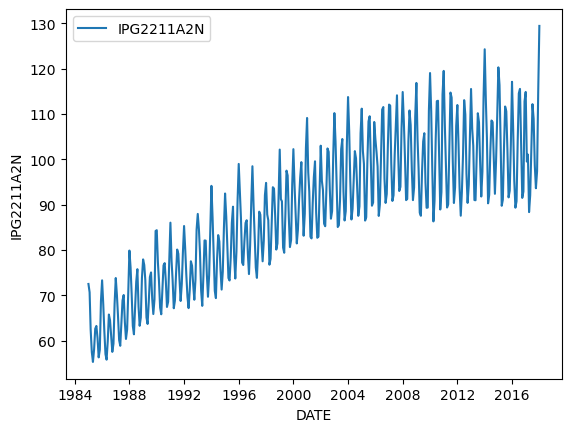

In [7]:
sns.lineplot(df)
plt.ylabel("IPG2211A2N")

#### The above is an multiplicative time series since we can see that the magnitudes are increasing futher and are not of same size 

#### The magnitude of seasonal fluctuations increases with time, indicating a multiplicative seasonal structure. The series is non-stationary with increasing variance, and hence a Holt–Winters multiplicative model or a log-transformed seasonal model is appropriate.

In [8]:
#The pattern and trend are amplifying hence we will be using multiplicative model for decomposition

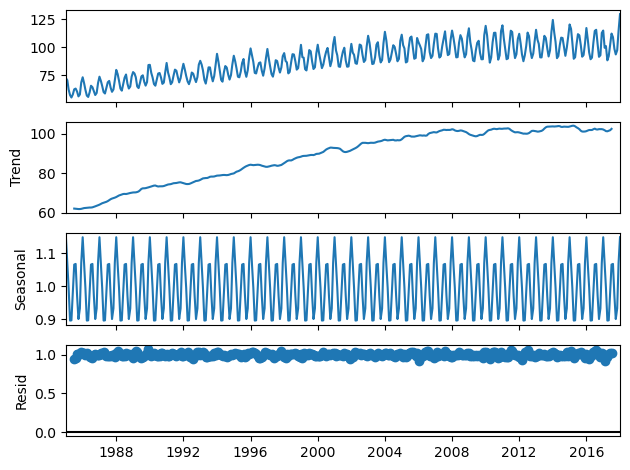

In [9]:
result = seasonal_decompose(df[['IPG2211A2N']], model = 'multiplicative',period = 12)
result.plot()
plt.show()

#### there is seasonality trend so it is a triplet

#### The time series exhibits a clear upward trend and strong monthly seasonality. The seasonal component is multiplicative in nature, as it fluctuates around one with constant proportional effects. The residuals show random behavior, indicating that the trend and seasonal components adequately explain the structure of the data.

In [12]:
import pymannkendall as mk

# Perform Mann-Kendall test
result = mk.original_test(df['IPG2211A2N'])
print(result)

# Check significance level
if result.p < 0.05:
    print("Reject H0: There is a significant monotonic trend in the series.")
    print("Trend type:", result.trend)
else:
    print("Fail to reject H0: No significant monotonic trend in the series.")


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(0.0), z=np.float64(19.125339232804578), Tau=np.float64(0.6427499173091112), s=np.float64(50524.0), var_s=6978466.0, slope=np.float64(0.11486610139860137), intercept=np.float64(67.03601192307693))
Reject H0: There is a significant monotonic trend in the series.
Trend type: increasing


In [40]:
#pvalue < 0.05 => reject H0. There is a Trend Present

In [13]:
train_df = df[:int(df.shape[0]*0.7)]
test_df = df[int(df.shape[0]*0.7):]

In [14]:
train_df.head()

,IPG2211A2N
DATE,
1985-01-01,72.5052
1985-02-01,70.6720
1985-03-01,62.4502
1985-04-01,57.4714
1985-05-01,55.3151


c:\Users\shraw\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


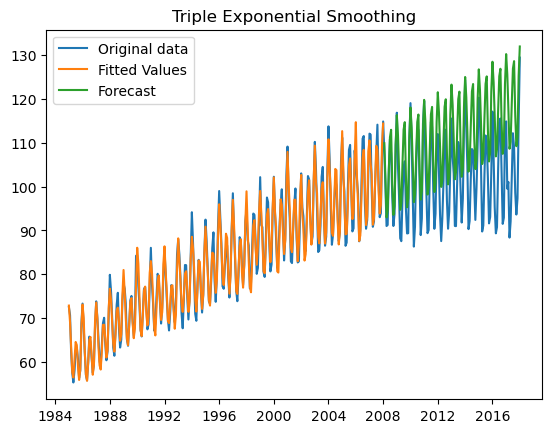

In [19]:
# Triple Exponential Smoothing (Holt-Winters)
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model_triple = ExponentialSmoothing(train_df , seasonal_periods=12 , trend ="add" , seasonal = "add")
model_triple_fit = model_triple.fit()

forecast_triple = model_triple_fit.forecast(len(test_df))

plt.plot(df , label = "Original data")
plt.plot(model_triple_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_triple , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Triple Exponential Smoothing")
plt.legend()
plt.show()

In [20]:
model_triplee = ExponentialSmoothing(train_df , seasonal_periods=12 , trend ="add" , seasonal = "mul")
model_triplee_fit = model_triplee.fit()

c:\Users\shraw\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [21]:
model_triplee_fit.params

{'smoothing_level': np.float64(0.6088574014337171),
 'smoothing_trend': np.float64(0.0),
 'smoothing_seasonal': np.float64(1.3905343851564427e-12),
 'damping_trend': nan,
 'initial_level': np.float64(47.953964084642465),
 'initial_trend': np.float64(0.09964903468313936),
 'initial_seasons': array([1.51904738, 1.41944934, 1.32961537, 1.19958555, 1.19381736,
        1.2997796 , 1.40750777, 1.41952894, 1.2910373 , 1.20080983,
        1.24093955, 1.41897156]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [22]:
forecast_triplee = model_triplee_fit.forecast(len(test_df))


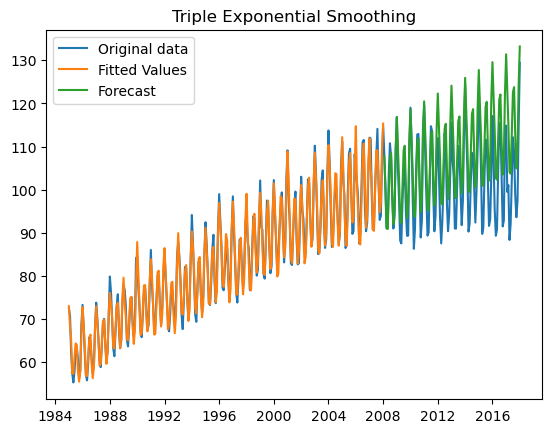

In [24]:
plt.plot(df , label = "Original data")
plt.plot(model_triplee_fit.fittedvalues , label="Fitted Values")
plt.plot(forecast_triplee , label = "Forecast")
plt.xlabel=("Year")
plt.ylabel =("Number of Passenger")
plt.title("Triple Exponential Smoothing")
plt.legend()
plt.show()

### Seasonal and Non - Seasonal Differencing

In [ ]:
# Seasonal and Non - Seasonal Differencing
sdiff = df[''].diff(periods = 12).dropna()
sddiff = sdiff.diff().dropna()
plt.figure(figsize=(14,3))
plt.grid()
plt.plot(sddiff)
plt.show()

In [1]:
# Import packages
import pandas as pd
import numpy as np
import os 
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose 
import seaborn as sns

In [2]:
df = pd.read_csv("C:\\myfols\\MSC\\sem2\\TSP\\Time Series AFTS SET- A\\Bikers.csv")

In [3]:
df

,Month,Ridership,t,Season
0,Jan-91,1709,1,Jan
1,Feb-91,1621,2,Feb
2,Mar-91,1973,3,Mar
3,Apr-91,1812,4,Apr
4,May-91,1975,5,May
...,...,...,...,...
154,Nov-03,2076,155,Nov
155,Dec-03,2141,156,Dec
156,Jan-04,1832,157,Jan
157,Feb-04,1838,158,Feb


In [4]:
df['Month'] = pd.to_datetime(df['Month'], format='%b-%y')

In [5]:
df

,Month,Ridership,t,Season
0,1991-01-01,1709,1,Jan
1,1991-02-01,1621,2,Feb
2,1991-03-01,1973,3,Mar
3,1991-04-01,1812,4,Apr
4,1991-05-01,1975,5,May
...,...,...,...,...
154,2003-11-01,2076,155,Nov
155,2003-12-01,2141,156,Dec
156,2004-01-01,1832,157,Jan
157,2004-02-01,1838,158,Feb


In [6]:
df.set_index('Month', inplace=True)
df = df[['Ridership']]

In [7]:
df

,Ridership
Month,
1991-01-01,1709
1991-02-01,1621
1991-03-01,1973
1991-04-01,1812
1991-05-01,1975
...,...
2003-11-01,2076
2003-12-01,2141
2004-01-01,1832


#### the above is a monthly data

Text(0, 0.5, 'Ridership')

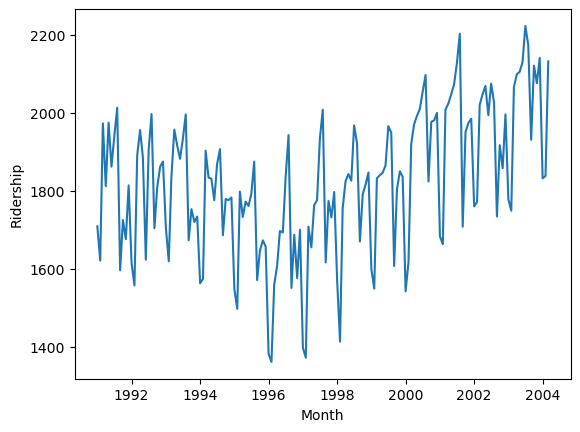

In [8]:
sns.lineplot(data=df, x=df.index, y='Ridership')
plt.ylabel('Ridership')

#### The time series shows an increasing trend and repeating monthly seasonal patterns with constant magnitude; therefore, the series is additive with seasonality.

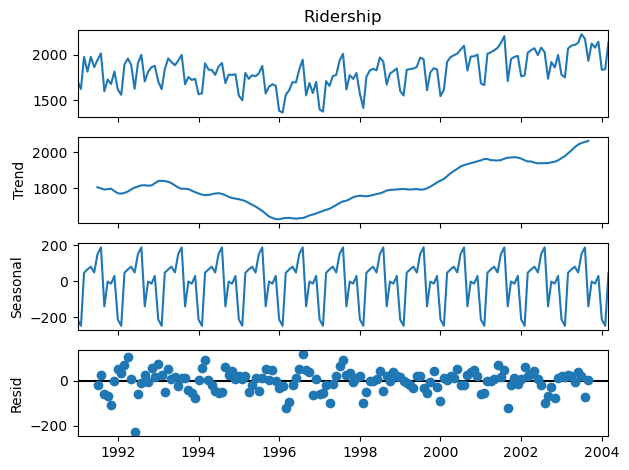

In [9]:
result = seasonal_decompose(df['Ridership'], model='additive', period=12)
result.plot()
plt.show()

#### There is an increasing trend in the data 
#### Seasonality is also present, and its an addative time sersies since the seasonal ups and downs stay roughly the same size over time

In [10]:
import pymannkendall as mk
mk.original_test(df['Ridership'])
#H0: No trend in the series
#H1: There is a trend in the series


Mann_Kendall_Test(trend='increasing', h=np.True_, p=np.float64(7.583033112545934e-08), z=np.float64(5.376778584224498), Tau=np.float64(0.28747711169492873), s=np.float64(3611.0), var_s=np.float64(450785.6666666667), slope=np.float64(1.7196969696969697), intercept=np.float64(1695.1439393939395))

#### since the pvalue < 0.05 we reject H0 i.e there is trend present in the data

In [11]:
train_df=df[:int(df.shape[0]*0.8)]
test_df=df[int(df.shape[0]*0.8):]

In [12]:
print(train_df.head())
print(test_df.head())

            Ridership
Month                
1991-01-01       1709
1991-02-01       1621
1991-03-01       1973
1991-04-01       1812
1991-05-01       1975
            Ridership
Month                
2001-08-01       2203
2001-09-01       1708
2001-10-01       1951
2001-11-01       1974
2001-12-01       1985


In [13]:
train_df.shape

(127, 1)

In [14]:
test_df.shape

(32, 1)

#### There is both trend sesonality present so we will use Triple exponential smoothing 

In [15]:
from statsmodels.tsa.api import ExponentialSmoothing
model_triple = ExponentialSmoothing(train_df, seasonal_periods=12, trend='add', seasonal='add')
model_triple_fit = model_triple.fit()

c:\Users\shraw\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [16]:
model_triple_fit.params

{'smoothing_level': np.float64(0.6069499913669402),
 'smoothing_trend': np.float64(0.03717412049835669),
 'smoothing_seasonal': np.float64(0.07696050467835823),
 'damping_trend': nan,
 'initial_level': np.float64(1901.275350803035),
 'initial_trend': np.float64(-2.9614887778604966),
 'initial_seasons': array([-207.95668532, -245.45866319,   63.23204801,   67.03199296,
         101.78422974,   49.1826878 ,  150.32900837,  207.72681537,
        -110.7540155 ,    7.33646477,  -10.33220505,   22.18073651]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [17]:
forecast_triple = model_triple_fit.forecast(len(test_df))

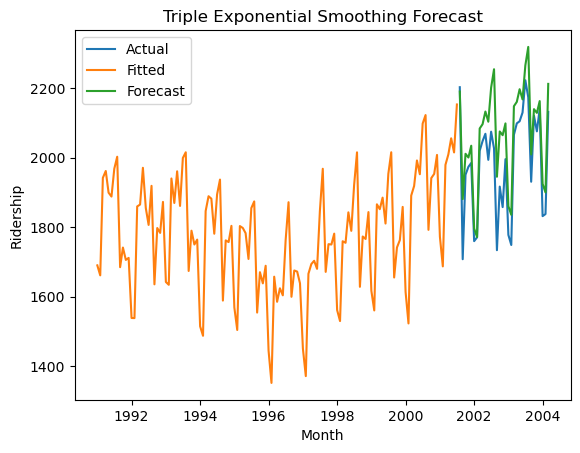

In [18]:
#Ridership ploting
plt.plot(test_df, label='Actual')
plt.plot(model_triple_fit.fittedvalues, label='Fitted')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Month')
plt.ylabel('Ridership')
plt.title('Triple Exponential Smoothing Forecast')
plt.legend()
plt.show()


In [19]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test = mean_absolute_percentage_error(test_df['Ridership'],forecast_triple)
print('MAPE for Test Data:', mape_test)

MAPE for Test Data: 0.04376048958215406


In [37]:
from statsmodels.tsa.api import ExponentialSmoothing
model_triple_mul = ExponentialSmoothing(train_df, seasonal_periods=12, trend='add', seasonal='mul')
model_triple_fit = model_triple_mul.fit()

c:\Users\shraw\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [38]:
model_triple_fit.params

{'smoothing_level': np.float64(0.5787836714562622),
 'smoothing_trend': np.float64(0.001995705149619455),
 'smoothing_seasonal': np.float64(0.15230134457419203),
 'damping_trend': nan,
 'initial_level': np.float64(1775.4519087246567),
 'initial_trend': np.float64(0.6094214452948615),
 'initial_seasons': array([0.98291473, 0.95171088, 1.14579   , 1.14216866, 1.17013603,
        1.12426081, 1.18746229, 1.23131132, 1.03245444, 1.10341308,
        1.08960343, 1.10839621]),
 'use_boxcox': False,
 'lamda': None,
 'remove_bias': False}

In [39]:
forecast_triple = model_triple_fit.forecast(len(test_df))

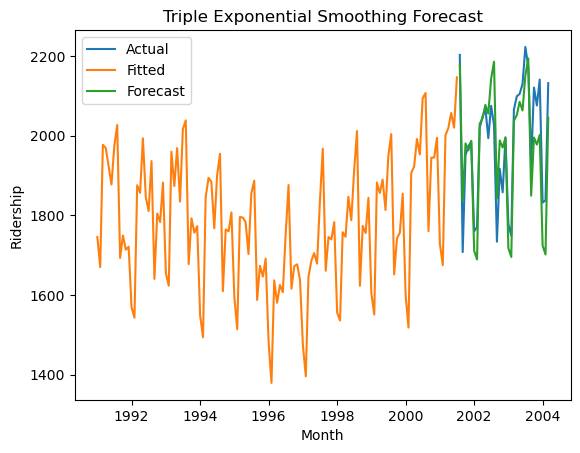

In [40]:
#Ridership ploting
plt.plot(test_df, label='Actual')
plt.plot(model_triple_fit.fittedvalues, label='Fitted')
plt.plot(forecast_triple, label='Forecast')
plt.xlabel('Month')
plt.ylabel('Ridership')
plt.title('Triple Exponential Smoothing Forecast')
plt.legend()
plt.show()


In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
mape_test = mean_absolute_percentage_error(test_df['Ridership'],forecast_triple)
print('MAPE for Test Data:', mape_test)

MAPE for Test Data: 0.03330531389743072


#### ADF TEST

In [20]:
## Null Hypothesis: Series is non-stationary, i.e, it has a unit root
## Alternative Hypothesis: Series is stationary, i.e, it does not have a unit root

In [21]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(df['Ridership'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -0.23499112877866932
p-value: 0.9342202042969283


#### p-value > 0.05 – Do not Reject Null Hypothesis(HO). Series is non-stationary

#### KPSS TEST

In [22]:
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.

In [23]:
from statsmodels.tsa.stattools import kpss
kp = kpss(df['Ridership'])
p = kp[1]
print("p-value for KPSS test (untransformed) = ", p)


p-value for KPSS test (untransformed) =  0.01


C:\Users\shraw\AppData\Local\Temp\ipykernel_51796\2963198994.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp = kpss(df['Ridership'])


#### Here p-value is less than 0.05 so reject Null Hypothesis i.e data is NOT trend stationary

#### In all of the above we found out that the data is non stationary hence we will make the data stationary

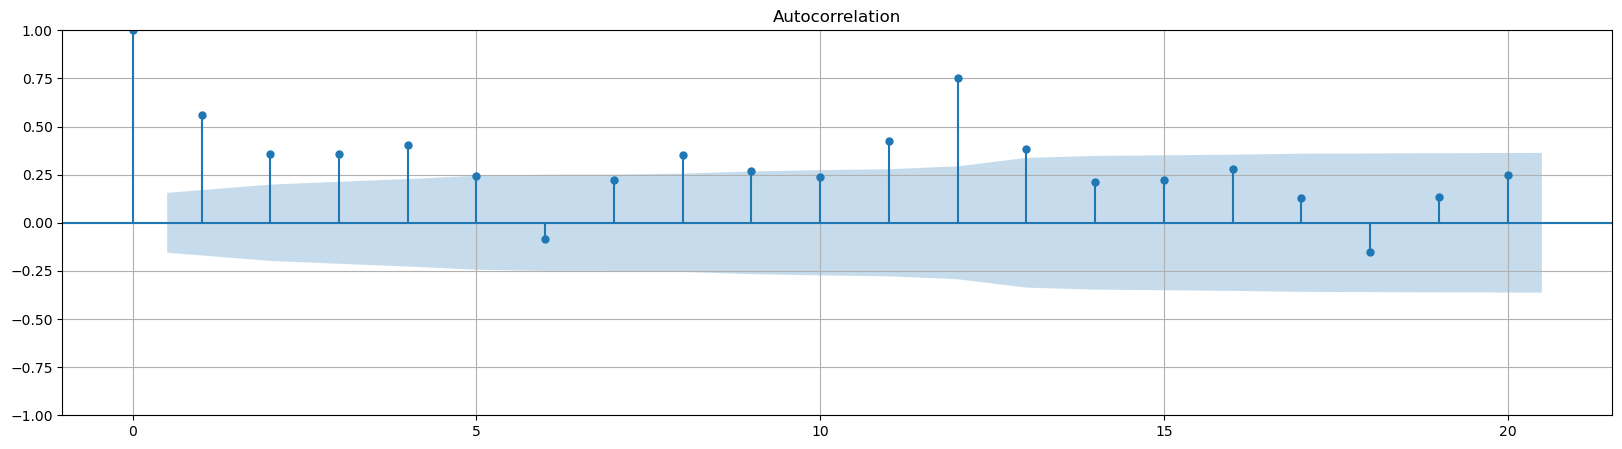

In [24]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(df['Ridership'] , ax=plt.gca(), lags = 20)
plt.show()

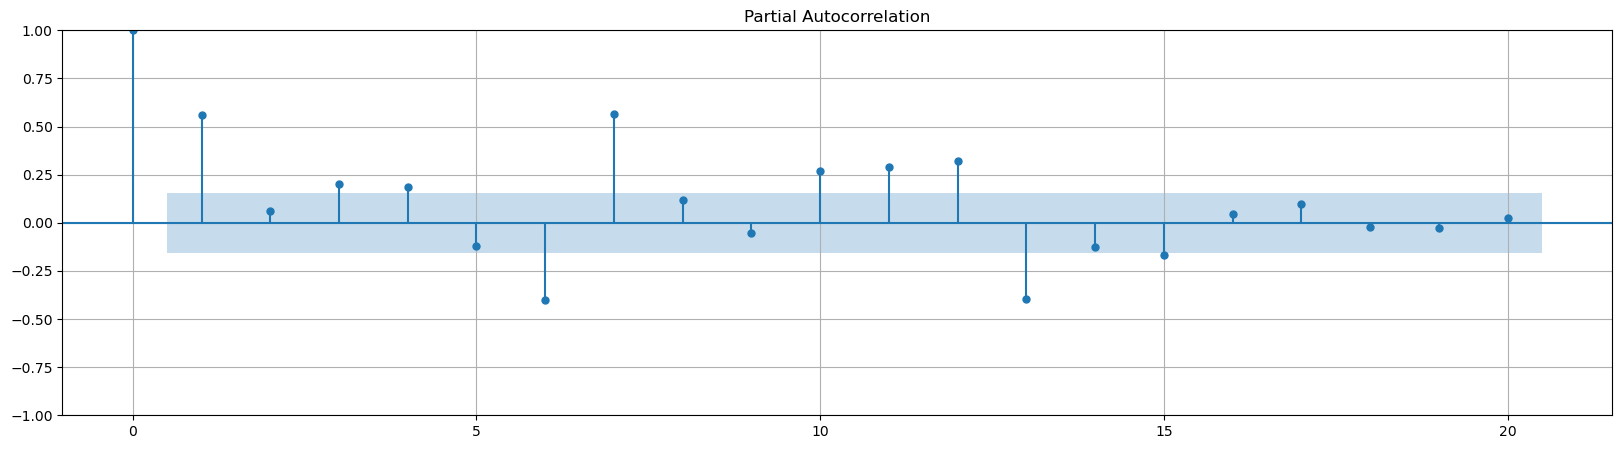

In [25]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(df['Ridership'] , ax=plt.gca(), lags = 20)
plt.show()

#### With the help of ACF and PACF we can see that values of lag are falling outside the significant region so we can conclude that our data is non-stationary

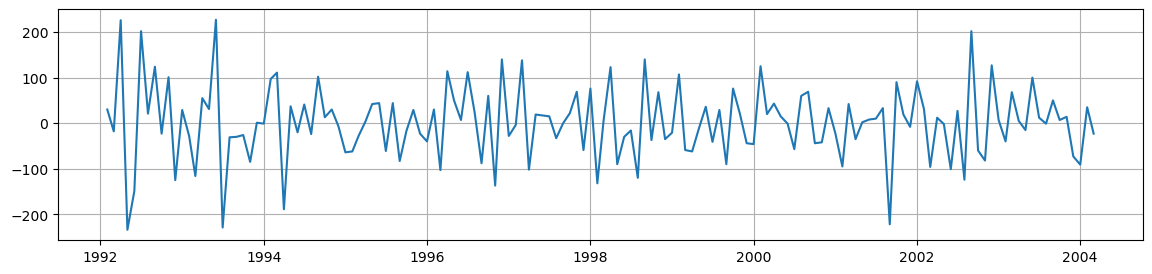

In [27]:
#SEASONAL AND NON-SEASONAL DIFFERENCING
sdiff = df['Ridership'].diff(periods = 12).dropna()  # seasonal differencing
sddiff = sdiff.diff().dropna()                          # non-seasonal differencing  # 1ST ORDER DIFFERENCING
plt.figure(figsize=(14, 3))
plt.grid()
plt.plot(sddiff)

plt.show()

In [35]:
#ADF
#Null Hypothesis (HO): Series is non-stationary, or series has a unit root.
#Alternate Hypothesis(HA): Series is stationary, or series has no unit root.
#p-value < 0.05 – Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import adfuller
result = adfuller(sdiff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -2.0262256100007714
p-value: 0.27519376656394934


#### Since the pvalue>0.05 we fail to reject null hypothesis i.e the data is non-stationary

In [34]:
#KPSS TEST
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.
#p-value < 0.05 –  Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import kpss
kp = kpss(sdiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.0300308048944144


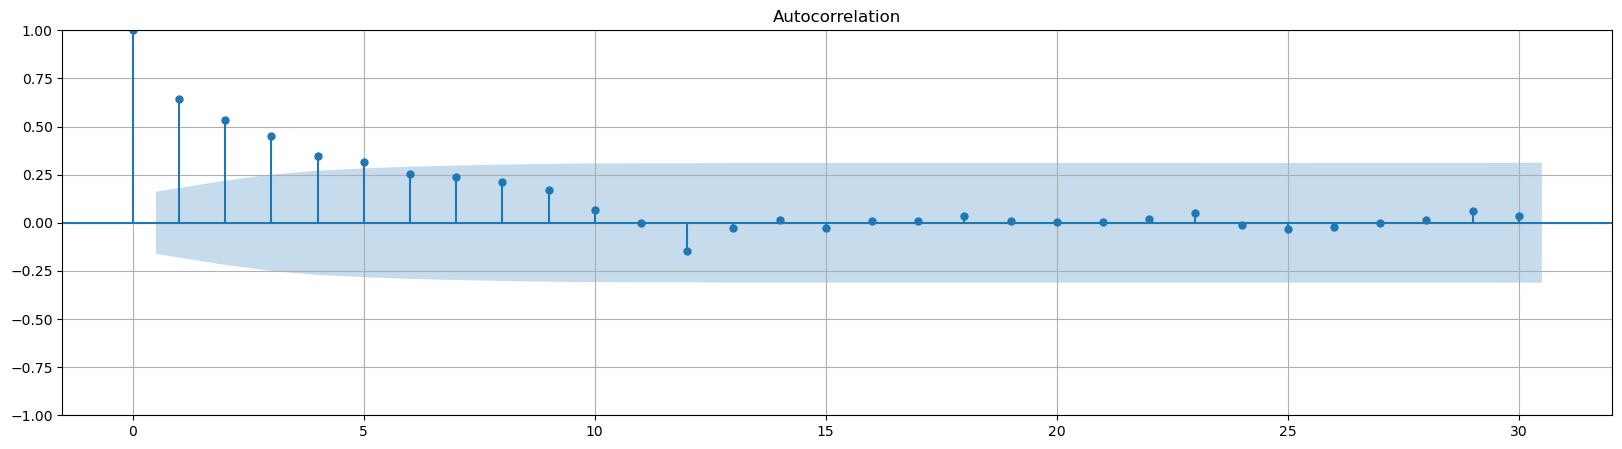

In [30]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(sdiff, ax=plt.gca(), lags =30 )
plt.show()

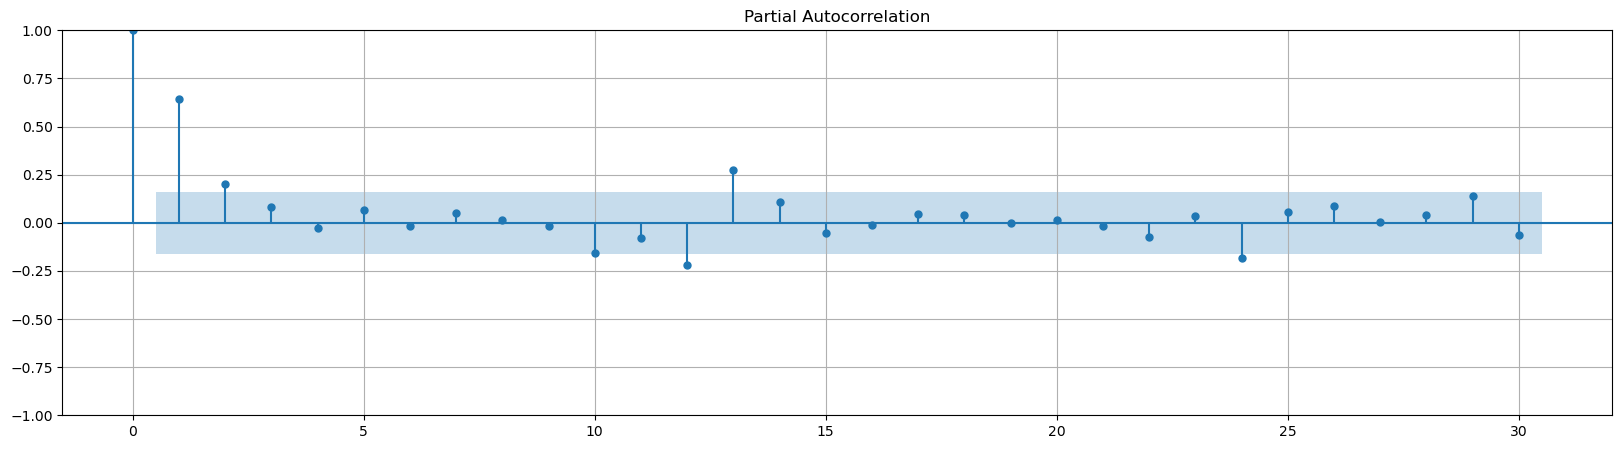

In [31]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(sdiff , ax=plt.gca(), lags = 30)
plt.show()

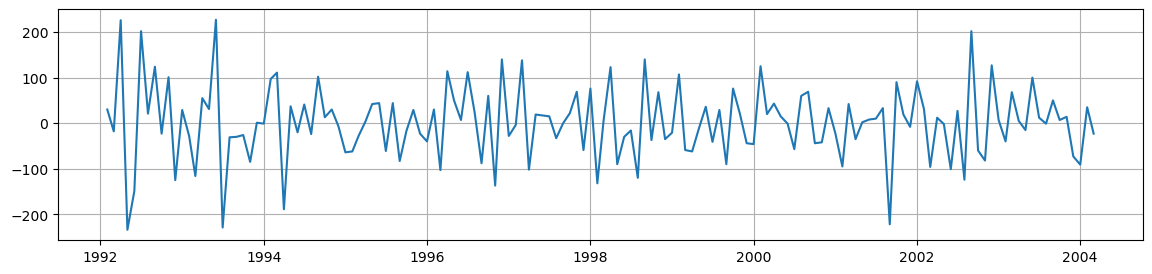

In [32]:
#SEASONAL AND NON-SEASONAL DIFFERENCING
sdiff = df['Ridership'].diff(periods = 12).dropna()  # seasonal differencing
sddiff = sdiff.diff().dropna()                          # non-seasonal differencing  # 1ST ORDER DIFFERENCING
plt.figure(figsize=(14, 3))
plt.grid()
plt.plot(sddiff)

plt.show()

In [33]:
#ADF
#Null Hypothesis (HO): Series is non-stationary, or series has a unit root.
#Alternate Hypothesis(HA): Series is stationary, or series has no unit root.
#p-value < 0.05 – Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import adfuller
result = adfuller(sddiff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.992381892566224
p-value: 2.2976649645742876e-05


In [43]:
#KPSS TEST
#Null Hypothesis (HO): Series is trend stationary or series has no unit root.
#Alternate Hypothesis(HA): Series is non-stationary, or series has a unit root.
#p-value < 0.05 –  Reject Null Hypothesis(HO)

from statsmodels.tsa.stattools import kpss
kp = kpss(sddiff)
p = kp[1]

print("p-value for KPSS test (untransformed) = ", p)

p-value for KPSS test (untransformed) =  0.1


C:\Users\shraw\AppData\Local\Temp\ipykernel_51796\2026258703.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kp = kpss(sddiff)


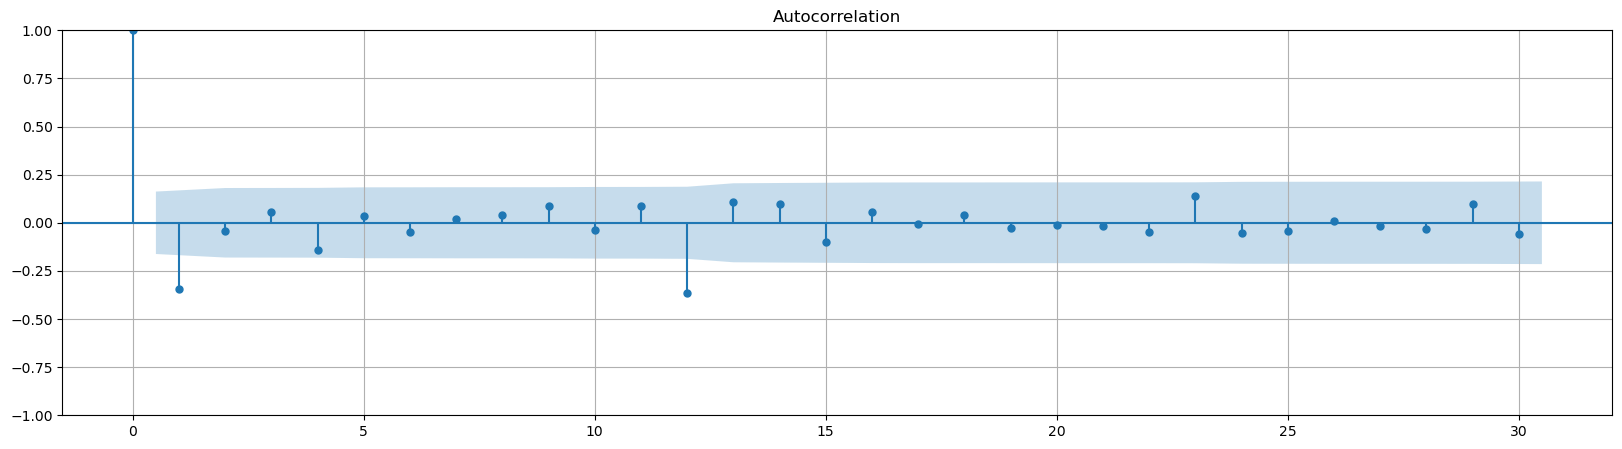

In [44]:
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
plt.figure(figsize=(20, 5))
plt.grid()
plot_acf(sddiff, ax=plt.gca(), lags =30 )
plt.show()

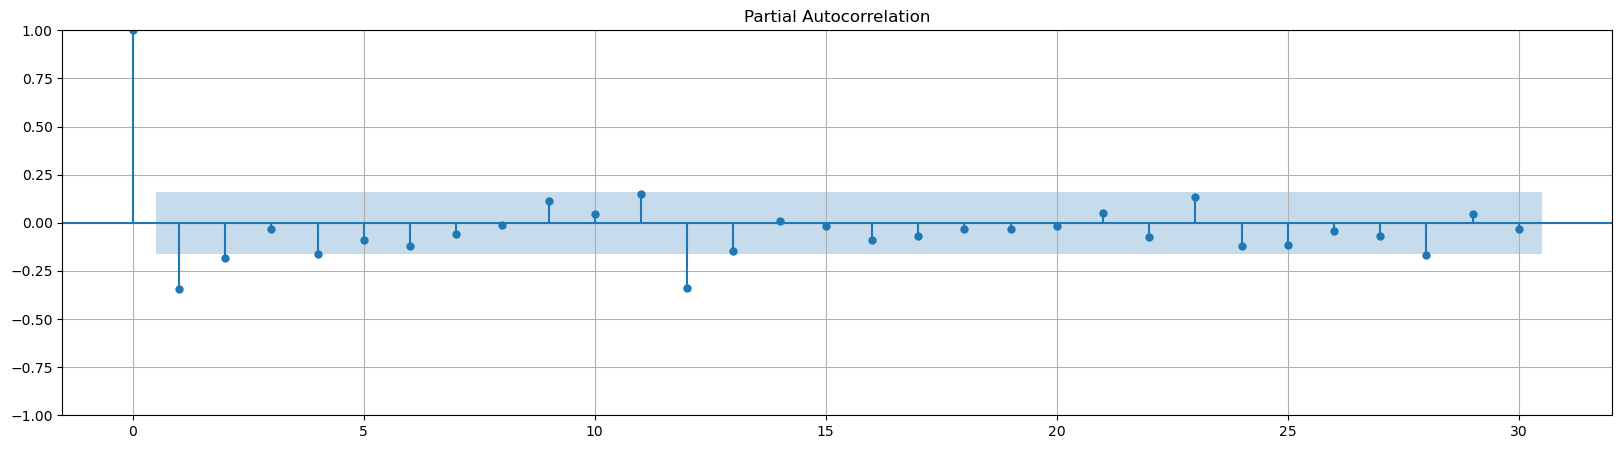

In [45]:
plt.figure(figsize=(20, 5))
plt.grid()
plot_pacf(sddiff , ax=plt.gca(), lags = 30)
plt.show()